#🧩 [Assignment 9] Dominant Colors — Clustering 🎨

In this assignment, you will explore unsupervised learning techniques to find the dominant colors in an image using K-Means and Self-Organizing Maps (SOM).

You’ll compare how each method clusters pixel colors.

##Step 0: Setting Up the Modules ⚙️

<font color=red>The following code installs the **minisom** module in your Colab environment.
Make sure to **comment out this cell** after you finish solving the assignment and **before submitting** to Gradescope.

*🕒 Installing extra modules during grading can **significantly slow down Gradescope execution.**
You don’t need to install it there — this package is already pre-installed on Gradescope. ✅*

In [ ]:
#Comment out this code before submitting your solution to the Gradescope.
#Run this code to install minisom
# !pip install minisom

  Preparing metadata (setup.py) ... done
  Created wheel for minisom: filename=MiniSom-2.3.5-py3-none-any.whl size=12031 sha256=45ddaa9307d87948dfce95e24b37a889f4cdbf1cf3a3069ad8718dad7f43c09a
  Stored in directory: /root/.cache/pip/wheels/0f/8c/a4/5b7aa56fa6ef11d536d45da775bcc5a2a1c163ff0f8f11990b
Successfully built minisom


In [1]:
#Import modules needed
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from minisom import MiniSom
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Step 1: Load an image

Download the `dominant-color.jpg` from canvas and upload it to Colab

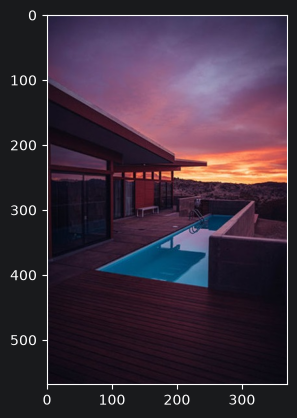

In [2]:
#run the code below to load the image and show it.
img = plt.imread('dominant-colors.jpg')
plt.imshow(img)

## Step 2: Preprocessing the Image 🖼️

If you print `img.shape`, you’ll see that the image you loaded has dimensions in the format:
`Height × Width × 3`

Your tasks:


1.   **Reshape** the image into a 2D array of shape `m × 3`, where each row represents a pixel and each column represents a color channel (R, G, B). Save this array as `img_reshaped`.
2.   **Normalize** the color features using `StandardScaler()` and save the normalized array as `img_reshaped_n`.

⚠️ Important: Do not change the name of the scaler — it must be called `stdScaler`.
This ensures compatibility with the automated grading on Gradescope.


In [3]:
from sklearn.preprocessing import StandardScaler
### BEGIN SOLUTION
print(img.shape)
img_reshaped = img.reshape(-1, 3)
stdScaler = StandardScaler()
img_reshaped_n = stdScaler.fit_transform(img_reshaped)


### END SOLUTION
print('Original img shape: ', img.shape)
print('Reshaped img shape: ', img_reshaped.shape)
print('Reshaped and normalized img shape: ', img_reshaped_n.shape)

(569, 370, 3)
Original img shape:  (569, 370, 3)
Reshaped img shape:  (210530, 3)
Reshaped and normalized img shape:  (210530, 3)


## Step 3: Implementing K-Means

Iterate through K= 2,3,4,..., 8 and Implement K-Means using the normalized features `img_shaped_n`  

*   Form a list called `Inertia_list` and for every value of K (in every iteration) append the Kmeans Inertia to the list
*   Form a list called `Silhouette_list` and for every value of K (in every iteration) append the silhouette score to the list

At the end of the following code block, you should have two lists each with **7 values** corresponding to K=2,3,....8.

<font color=red>**Silhouette Implemenation Note:**</font> Calculating Silhouette coefficient is computationally extensive. Therefore, we will compute Silhouette coefficient on a random sub sample of our data instead of running it on all data. The parameter `sample_size` specify the number of samples we want to be used for computing the coefficient. If we do not provide this parameter, Colab will take a long time and it may not give us the coefficient. So use the Silhouette function with the following three parameters:

*  sample_size=35000
*  random_state=10
*  n_jobs=-1

Basically, in this example we compute Silhouette for ~15% of data (we have ~210k total records)



In [45]:
Inertia_list=[]
Silhouette_list=[]

### BEGIN SOLUTION

for k in range(2,9):
    km = KMeans(n_clusters=k)
    km.fit(img_reshaped_n)
    Inertia_list.append(km.inertia_)
    sil_score = silhouette_score(img_reshaped_n, km.labels_, sample_size=35000, random_state=10, n_jobs=-1)
    Silhouette_list.append(sil_score)





### END SOLUTION


Running the following code block will give you the trend of KMeans Error and Silhouette Score.

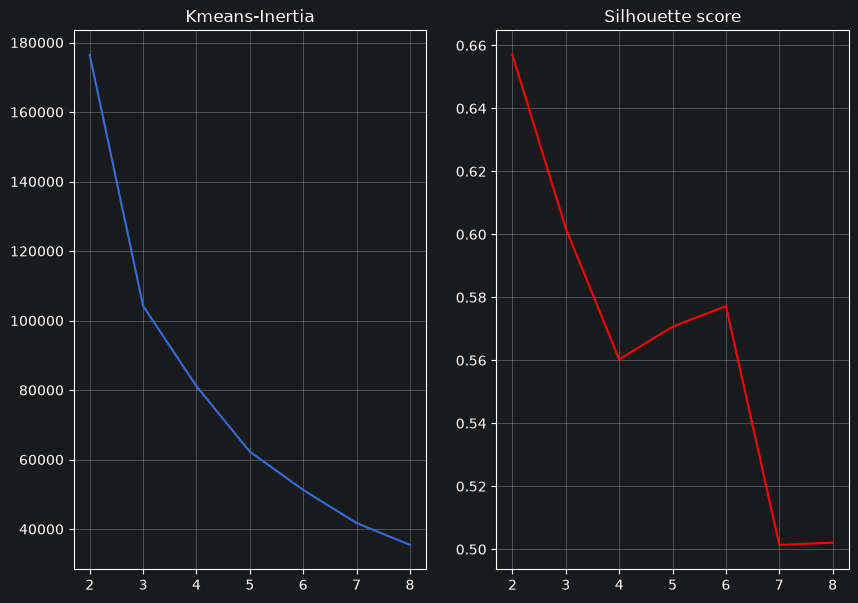

In [46]:
plt.figure(figsize=(10,7))
plt.subplot(1,2,1)
plt.plot([i for i in range(2,9)],Inertia_list)
plt.title('Kmeans-Inertia')
plt.grid()
plt.subplot(1,2,2)
plt.plot([i for i in range(2,9)],Silhouette_list,color='red')
plt.title('Silhouette score')
plt.grid()

## Step 4: Selecting the best K

Based on the graphs above, select the best k, set the value of k in the following block to re-run the KMeans for the selected value of k

In [34]:
#Set the Value of K based on the graphs above
# Arguably, you haven't hit the knee of the k-means curve, so you could increase the cluster count further.
# However, because the silhouette score is decreasing consistently, you should decrease the cluster count.
# Pareto best is k=4
Best_K = 4

kmeans = KMeans(n_clusters=Best_K, init= "random")
kmeans.fit(img_reshaped_n)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'random'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 3)","[[

## Step 5: Replace colors with KMeans centroids!



1.   Form a numpy array called `img_clustered_reshaped_n` which has the exact number of records as the `img_reshaped_n`, and replace the colors (values of the records) with the centroid color that the record belongs to.
2.   Reverse the normalization that you did with `stdScaler` and modify `img_clustered_reshaped_n` to be `img_clustered_reshaped`
3.   Reshape the `img_clustered_reshaped` to have the shape of the original image `Height x Width x 3` and name it `img_clustered`





In [35]:
### BEGIN SOLUTION

img_clustered_reshaped_n = kmeans.cluster_centers_[kmeans.labels_]

img_clustered_reshaped = stdScaler.inverse_transform(img_clustered_reshaped_n)

img_clustered = img_clustered_reshaped.reshape(img.shape)

### END SOLUTION

If your code in the block above is written correctly, the modified image (with dominant colors) should show up after running the following block of code.

Text(0.5, 1.0, 'KMeans')

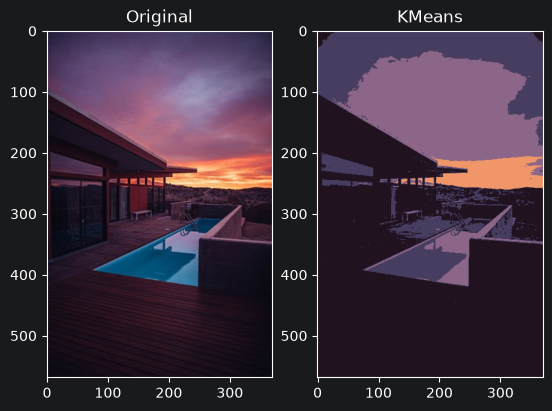

In [36]:
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original")
plt.subplot(1,2,2)
plt.imshow(img_clustered.astype(int))
plt.title("KMeans")

Run the following code, should give us the centroids - Dominant colors!

In [37]:
centroids = stdScaler.inverse_transform(kmeans.cluster_centers_)
centroids

array([[140.71625882, 102.30141334, 136.02873871],
       [ 70.28395268,  61.85710538,  96.25678577],
       [ 32.44868439,  18.0077209 ,  31.27076354],
       [240.99864001, 150.1755746 , 105.95076839]])

## Step 6: Implementing SOM

Define a SOM with network of 5 by 5 perceptrons called `SOM_Model`. Train the defined model on `img_reshaped_n` till you achieve <font color=red> quantization error less than 0.35 </font>

You should only modify the following parameters:

*   sigma
*   learning_rate
*   number of iterations (you are **not** allowed to have a number of iteration larger than 150000)

In [38]:
### BEGIN SOLUTION

from sklearn.model_selection import ParameterGrid

# Define parameter grid - for autograder
param_grid = {
    'sigma': [0.75],
    'learning_rate': [0.01]
}
# What I used to find the parameters.
# param_grid = {
#     'sigma': [0.05, 0.1, 0.5, 0.75, 1.0],
#     'learning_rate': [0.01, 0.05, 0.1, 0.5]
# }

best_error = float('inf')
best_params = None
best_model = None

# Grid search
for params in ParameterGrid(param_grid):
    SOM_Model = MiniSom(5, 5, 3, sigma=params['sigma'], learning_rate=params['learning_rate'], random_seed=10)
    SOM_Model.train(img_reshaped_n, 150000)
    error = SOM_Model.quantization_error(img_reshaped_n)

    if error < best_error:
        best_error = error
        best_params = params
        best_model = SOM_Model

print(f"Best parameters: {best_params}")
print(f"Best quantization error: {best_error}")

SOM_Model = best_model
### END SOLUTION


Best parameters: {'learning_rate': 0.01, 'sigma': 0.75}
Best quantization error: 0.25899689339926124


Run the following block of code to see the quantization error

In [39]:
SOM_Model.quantization_error(img_reshaped_n)

np.float64(0.25899689339926124)

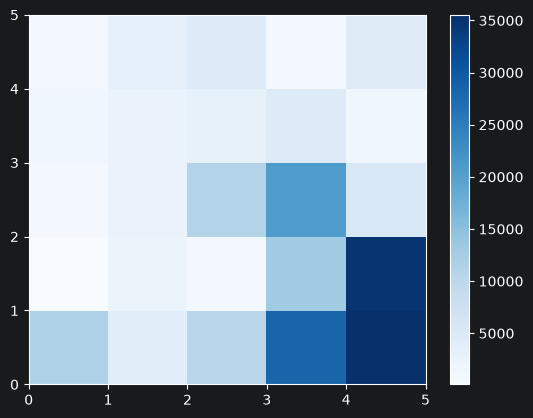

In [40]:
plt.pcolor(SOM_Model.activation_response(img_reshaped_n).T, cmap='Blues')
plt.colorbar()
plt.show()

## Step 7: Color Quantization

1.   Quantize the colors in `img_reshaped_n` using the trained SOM model `SOM_Model` and call it `img_reshaped_n_qnt`
2.   Use the `stdScaler` to reverse the normalization and form an array called `img_reshaped_qnt`
2.   Reshape the `img_reshaped_qnt` to have the shape of the original image `Height x Width x 3` and call it `img_qnt`

In [41]:
### BEGIN SOLUTION

img_reshaped_n_qnt = np.array([SOM_Model.get_weights()[SOM_Model.winner(x)] for x in img_reshaped_n])

img_reshaped_qnt = stdScaler.inverse_transform(img_reshaped_n_qnt)

img_qnt = img_reshaped_qnt.reshape(img.shape)

### END SOLUTION


Run the following block of code to see the

the original image,

1.   Orikginal image
2.   Image quantized using KMeans
3.   Image Quantized using SOM



Text(0.5, 1.0, 'SOM')

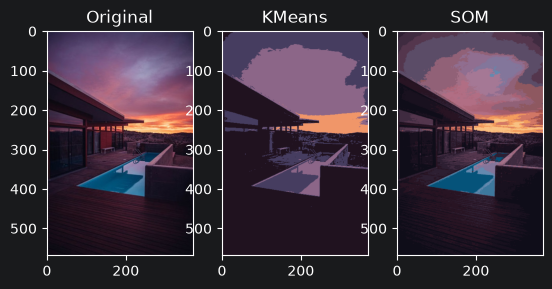

In [42]:
plt.subplot(1,3,1)
plt.imshow(img)
plt.title('Original')

plt.subplot(1,3,2)
plt.imshow(img_clustered.astype(int))
plt.title('KMeans')

plt.subplot(1,3,3)
plt.imshow(img_qnt.astype(int))
plt.title('SOM')


Run the following block of code to the dominant colors identified by KMeans and dominant colors identified by SOM

Text(0.5, 1.0, 'Dominant Colors - SOM')

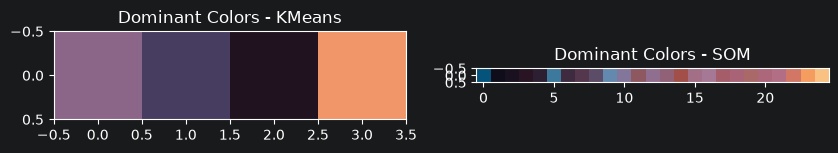

In [43]:
plt.figure(figsize=(10,10))
plt.subplot(1,2,1)
plt.imshow(centroids.reshape(1,4,3).astype(int))
plt.title('Dominant Colors - KMeans')
plt.subplot(1,2,2)
plt.imshow(stdScaler.inverse_transform(np.unique(img_reshaped_n_qnt, axis=0)).reshape(1,np.unique(img_reshaped_n_qnt, axis=0).shape[0],3).astype(int))
plt.title('Dominant Colors - SOM')

Yes we used more colors for SOM but Dominant Colors found by KMeans are similar to some of the dominant colors of SOM!